# 12 — Exploratory security, care & appearance

**All analyses in this notebook are exploratory.** Topic sets are intentionally broader
than the frozen confirmatory constructs and **do not alter H1–H6 verdicts.**

Questions addressed:
- How does δ change as we broaden semantic definitions (strict → moderate → broad)?
- Which kinds of security promises distinguish high-rated romance?
- Presence vs conditional intensity of themes
- Danger × protection interaction
- Emotional security × appearance quadrants
- Fractional protection weights for mixed violence topics

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import exploratory_security as ex
from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("12_exploratory_security_care_appearance")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
exp_cfg = ex.load_exploratory_config(root / "configs/stage11/exploratory_security_care_appearance.yaml")
families = exp_cfg["families"]
promise_types = exp_cfg["promise_types"]
presence_threshold = float(exp_cfg.get("presence_threshold", 1e-5))

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance


In [2]:
frame = nh.load_refined_frame(cfg, "strict")
if "book_id" in frame.columns:
    frame = frame.set_index("book_id")
usable = frame[frame["analysable"].fillna(True)].copy() if "analysable" in frame.columns else frame.copy()
work = usable.reset_index()
if "book_id" not in work.columns and usable.index.name == "book_id":
    work["book_id"] = usable.index

shares = ex.topic_share_matrix(cfg)
master = pd.read_parquet(cfg.output_path("constructs_dir") / "master_annotations.parquet")

frac_cfg = exp_cfg.get("fractional_protection") or {}
frac_topics = frac_cfg.get("candidate_topics") or families["enacted_protection"].get("fractional_topics") or []
frac_weights = ex.build_fractional_protection_weights(
    cfg,
    candidate_topics=frac_topics,
    protection_codes=frac_cfg.get("protection_codes"),
)
weights_path = ctx.tables_dir / "exploratory_protection_weights.json"
ex.save_fractional_weights_json(frac_weights, weights_path)
print(f"Fractional protection weights saved → {weights_path}")
display(pd.Series(frac_weights, name="W_t_protection").sort_values(ascending=False))

Fractional protection weights saved → /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/exploratory_protection_weights.json


Series([], Name: W_t_protection, dtype: object)

,family,level,feature,n_topics,cliffs_delta,ci_low,ci_high,verdict,note
0,emotional_security,strict,EXP_emotional_security_strict,10,0.0377,0.0164,0.0583,directional_only,
1,emotional_security,moderate,EXP_emotional_security_moderate,29,0.0642,0.0412,0.0888,directional_only,
2,emotional_security,broad,EXP_emotional_security_broad,45,0.1015,0.0787,0.1225,directional_only,
3,protective_commitment,strict,EXP_protective_commitment_strict,0,NaN,NaN,NaN,unmeasurable,zero topics
4,protective_commitment,moderate,EXP_protective_commitment_moderate,5,0.1687,0.1487,0.1890,clears_gate,
5,protective_commitment,broad,EXP_protective_commitment_broad,14,0.0003,-0.0205,0.0238,no reliable effect,
6,enacted_protection,strict,EXP_enacted_protection_strict,1,0.1597,0.1410,0.1816,clears_gate,
7,enacted_protection,moderate,EXP_enacted_protection_moderate,3,0.1597,0.1410,0.1816,clears_gate,
8,enacted_protection,broad,EXP_enacted_protection_broad,10,0.1597,0.1410,0.1816,clears_gate,
9,practical_care,strict,EXP_practical_care_strict,4,0.0573,0.0353,0.0770,directional_only,


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/strict_moderate_broad_trajectories.csv  (21 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/figures/trajectory_plot.png


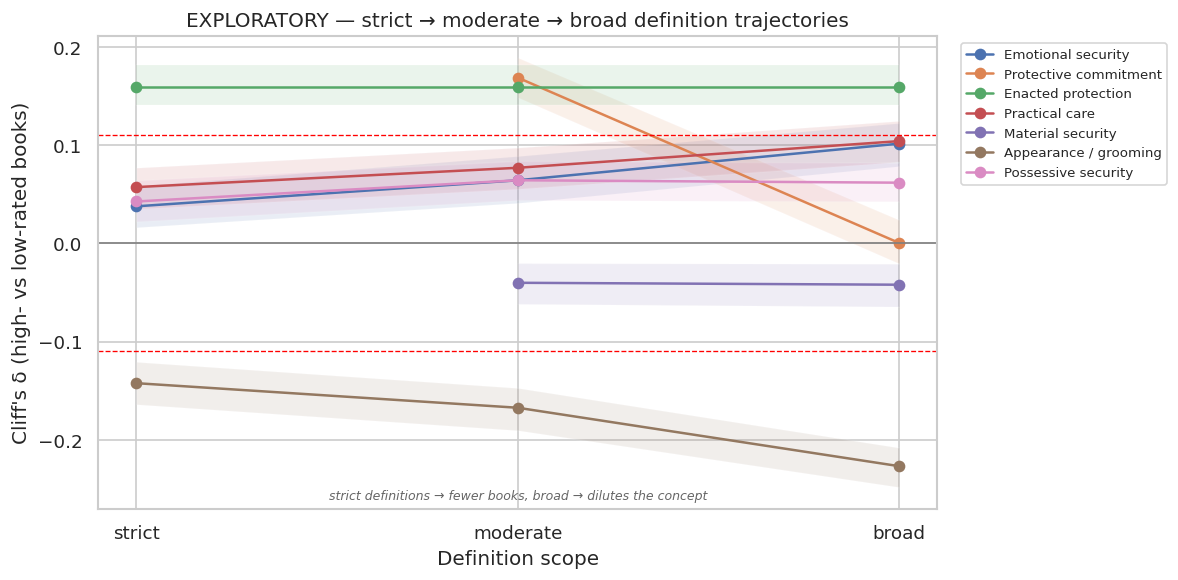

In [3]:
work_exp = ex.add_topic_set_columns(work, shares, families, fractional_weights=frac_weights)

def _test(df, feat, hyp, label=""):
    return nh.test_axis(
        df,
        feat,
        hyp,
        label=label,
        measurement_gate="viable",
        effect_gate=GATE,
        expected_sign=None,
        n_replicates=400,
        seed=42,
    )

trajectories = ex.trajectory_effects(work_exp, families, test_fn=_test)
display(trajectories.round(4))
ctx.save_table(trajectories, "strict_moderate_broad_trajectories")

# Trajectory plot — skip unmeasurable (0-topic) points; never plot δ=0 for empty sets
_FAMILY_HUMAN = {
    "enacted_protection": "Enacted protection",
    "emotional_security": "Emotional security",
    "appearance": "Appearance / grooming",
    "protective_commitment": "Protective commitment",
    "protective_care_broad": "Protective care (broad)",
}

fig, ax = plt.subplots(figsize=(10, 5))
level_order = ["strict", "moderate", "broad"]
for family in trajectories["family"].unique():
    sub = trajectories[trajectories["family"] == family].set_index("level").reindex(level_order)
    y = sub["cliffs_delta"].astype(float)
    if y.isna().all():
        continue
    ax.plot(level_order, y, marker="o", label=_FAMILY_HUMAN.get(family, family.replace("_", " ").capitalize()))
    mask = y.notna()
    if mask.any():
        lo = sub["ci_low"].astype(float)
        hi = sub["ci_high"].astype(float)
        xs = [i for i, m in enumerate(mask) if m]
        ax.fill_between(
            xs,
            lo[mask].to_numpy(),
            hi[mask].to_numpy(),
            alpha=0.12,
        )
ax.axhline(0, color="gray", lw=1)
ax.axhline(GATE, color="red", ls="--", lw=0.8)
ax.axhline(-GATE, color="red", ls="--", lw=0.8)
ax.set_xlabel("Definition scope")
ax.set_ylabel("Cliff's δ (high- vs low-rated books)")
ax.set_title("EXPLORATORY — strict → moderate → broad definition trajectories")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.annotate("strict definitions → fewer books, broad → dilutes the concept",
            xy=(0.5, 0.02), xycoords="axes fraction", ha="center", fontsize=7.5,
            color="#666666", style="italic")
plt.tight_layout()
ctx.save_figure(fig, "trajectory_plot")
plt.show()

## Per-topic forest (broad enacted protection + emotional security)

In [4]:
forest_frames = []
for family, level in [("enacted_protection", "broad"), ("emotional_security", "broad")]:
    tids = families[family].get(level) or []
    forest = ex.topic_level_forest(shares, work, tids, master, test_fn=_test)
    forest.insert(0, "family", family)
    forest_frames.append(forest)
forest_all = pd.concat(forest_frames, ignore_index=True)
display(forest_all.sort_values("cliffs_delta", ascending=False).round(4))
ctx.save_table(forest_all, "topic_forest_broad_families")

,family,topic_id,topic_label,taxonomy_id,cliffs_delta,ci_low,ci_high,verdict
1,enacted_protection,78,Swearing War Before He Takes Her,7.2,0.1648,0.1420,0.1861,clears_gate
2,enacted_protection,87,Threatening Death As A Warning,7.2,0.1619,0.1409,0.1829,clears_gate
20,emotional_security,119,Offering to Keep Her Safe,4.6,0.1597,0.1410,0.1816,clears_gate
7,enacted_protection,119,Offering to Keep Her Safe,4.6,0.1597,0.1410,0.1816,clears_gate
29,emotional_security,238,Relaying A Message For Her,9.2,0.1480,0.1270,0.1702,clears_gate
43,emotional_security,372,Told to Keep Up Strength,4.6,0.1448,0.1225,0.1649,clears_gate
16,emotional_security,56,Promising Never to Hurt You,4.6,0.1377,0.1175,0.1574,clears_gate
27,emotional_security,193,Nurse Arranged After Hospital Release,4.6,0.1353,0.1143,0.1537,clears_gate
5,enacted_protection,114,Guns Aimed Across The Room,7.2,0.1306,0.1087,0.1539,clears_gate
6,enacted_protection,122,Wound Bleeding and Blood Loss,1.2,0.1288,0.1099,0.1509,clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/topic_forest_broad_families.csv  (55 rows)


,promise_type,n_topics,cliffs_delta,ci_low,ci_high,verdict,note
5,protective_commitment,4,0.2098,0.1890,0.2321,clears_gate,
6,enacted_external_protection,1,0.1597,0.1410,0.1816,clears_gate,
1,non_harm_safety,1,0.1377,0.1175,0.1574,clears_gate,
2,emotional_reassurance,4,0.1045,0.0823,0.1275,directional_only,
0,trust_reliability,1,0.0934,0.0725,0.1128,directional_only,
7,practical_care,5,0.0595,0.0368,0.0791,directional_only,
9,possessive_protection,3,0.0426,0.0223,0.0641,directional_only,
3,belonging_presence,3,-0.0144,-0.0334,0.0066,no reliable effect,
4,long_term_partnership,3,-0.0193,-0.0422,0.0002,no reliable effect,
8,material_provision,5,-0.0402,-0.0616,-0.0202,directional_only,


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/promise_type_comparison.csv  (10 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/figures/promise_type_forest.png


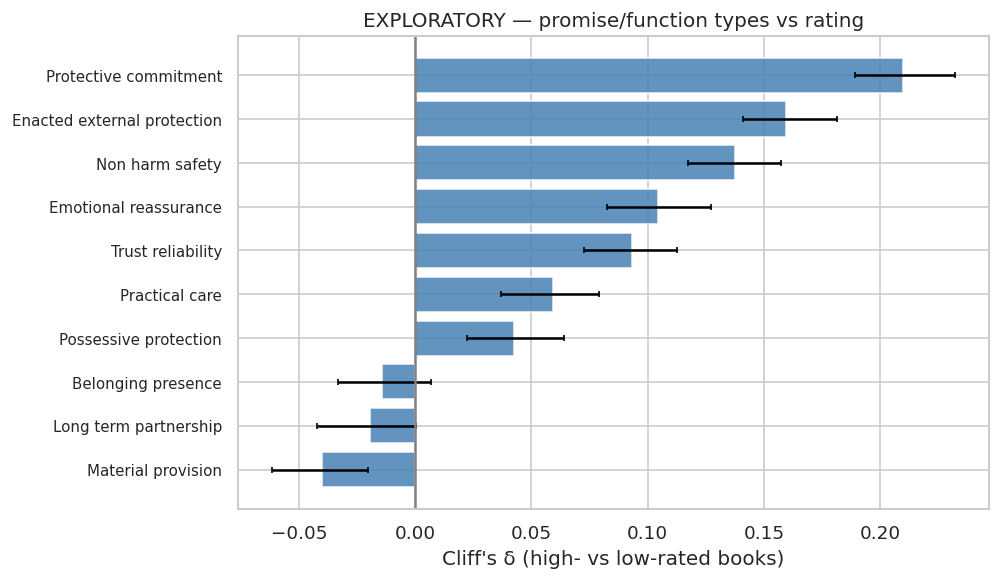

In [5]:
# Promise-type comparison table
promise_rows = []
for pname, tids in promise_types.items():
    tids = list(tids or [])
    if len(tids) == 0:
        promise_rows.append(
            {
                "promise_type": pname,
                "n_topics": 0,
                "cliffs_delta": float("nan"),
                "ci_low": float("nan"),
                "ci_high": float("nan"),
                "verdict": "unmeasurable",
                "note": "zero topics",
            }
        )
        continue
    col = f"EXP_promise_{pname}"
    tmp = work.copy()
    share = ex.topic_set_share(shares, tids)
    tmp[col] = ex._align_series_to_frame(share, tmp).values
    res = _test(tmp, col, "EXP", label=pname.replace("_", " "))
    promise_rows.append(
        {
            "promise_type": pname,
            "n_topics": len(tids),
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
            "note": "",
        }
    )
promise_df = pd.DataFrame(promise_rows).sort_values("cliffs_delta", ascending=False)
display(promise_df.round(4))
ctx.save_table(promise_df, "promise_type_comparison")

_PROMISE_HUMAN = {
    "protective_commitment": "Protective commitment",
    "enacted_external_protection": "Enacted external protection",
    "emotional_reassurance": "Emotional reassurance",
    "generic_safety_promise": "Generic safety promise",
    "possessive_guarding": "Possessive guarding",
}

fig, ax = plt.subplots(figsize=(8.5, 5))
plot_p = promise_df.dropna(subset=["cliffs_delta"]).sort_values("cliffs_delta")
y = np.arange(len(plot_p))
ax.barh(y, plot_p["cliffs_delta"], color="steelblue", alpha=0.85)
ax.errorbar(
    plot_p["cliffs_delta"],
    y,
    xerr=[
        plot_p["cliffs_delta"] - plot_p["ci_low"],
        plot_p["ci_high"] - plot_p["cliffs_delta"],
    ],
    fmt="none",
    ecolor="black",
    capsize=2,
)
ax.set_yticks(y)
ax.set_yticklabels(
    [_PROMISE_HUMAN.get(str(v), str(v).replace("_", " ").capitalize()) for v in plot_p["promise_type"]],
    fontsize=9,
)
ax.axvline(0, color="gray")
ax.set_xlabel("Cliff's δ (high- vs low-rated books)")
ax.set_title("EXPLORATORY — promise/function types vs rating")
plt.tight_layout()
ctx.save_figure(fig, "promise_type_forest")
plt.show()

## Protective-commitment +.210 audit (exploratory)

The promise-type **protective_commitment** δ ≈ +.21 uses four deliberately selected
topics. Family-level `protective_commitment` is empty at strict (unmeasurable),
moderate ≈ +.17, and **broad (~14 topics) collapses to ~0**. Specific promise forms
matter; “promises of protection” as a broad category do not.

Fractional enacted-protection weights come from H4 Pass-B *sampled* contextual
sentences — not a full-topic census. Mixed violence topics (e.g. 87) can contain
protective speech without being clean protection topics.

In [6]:
pc_tids = list(promise_types.get("protective_commitment") or [])
pc_audit = ex.topic_level_forest(shares, work, pc_tids, master, test_fn=_test)
pc_audit.insert(0, "bundle", "promise_protective_commitment")
# Bundle-level δ for reference
pc_bundle = promise_df[promise_df["promise_type"] == "protective_commitment"]
if len(pc_bundle):
    pc_audit["bundle_cliffs_delta"] = float(pc_bundle.iloc[0]["cliffs_delta"])
display(pc_audit.round(4))
ctx.save_table(pc_audit, "protective_commitment_topic_audit")

# Fractional weights with Pass-B caveat
frac_tbl = (
    pd.Series(frac_weights, name="W_t_protection")
    .rename_axis("topic_id")
    .reset_index()
    .sort_values("W_t_protection", ascending=False)
)
frac_tbl["note"] = "Pass-B sampled sentences; not full-topic census"
display(frac_tbl.round(4))
ctx.save_table(frac_tbl, "fractional_protection_weights_table")

# Topic-id overlap: broad enacted protection vs RAX_external_danger_crisis
broad_prot = list(families.get("enacted_protection", {}).get("broad") or [])
danger_tids = ex.construct_topic_ids_from_w_tk(cfg, "RAX_external_danger_crisis")
overlap_df = ex.protection_danger_topic_overlap(broad_prot, danger_tids)
overlap_df["protection_topic_ids"] = ",".join(str(t) for t in sorted(broad_prot))
overlap_df["danger_topic_ids"] = ",".join(str(t) for t in danger_tids)
display(overlap_df)
ctx.save_table(overlap_df, "protection_danger_topic_overlap")
print(
    "Conceptual caveat: even with empty topic-id overlap, mixed violence topics "
    "receiving fractional protection weight may co-occur with danger discourse."
)

,bundle,topic_id,topic_label,taxonomy_id,cliffs_delta,ci_low,ci_high,verdict,bundle_cliffs_delta
0,promise_protective_commitment,247,Promising You Will Not Be Alone,4.6,0.0528,0.0286,0.0736,directional_only,0.2098
1,promise_protective_commitment,299,Pledging to Have Your Back,4.6,0.0386,0.0192,0.0597,directional_only,0.2098
2,promise_protective_commitment,338,Promising Never to Do That Again,9.2,0.0996,0.0808,0.1187,directional_only,0.2098
3,promise_protective_commitment,100,Promising to Find Her,9.2,0.2249,0.2066,0.2442,clears_gate,0.2098


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/protective_commitment_topic_audit.csv  (4 rows)


,topic_id,W_t_protection,note


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/fractional_protection_weights_table.csv  (0 rows)


,n_protection_topics,n_danger_topics,n_overlap,overlap_topic_ids,note,protection_topic_ids,danger_topic_ids
0,10,5,0,,empty topic-id overlap,"68,78,87,107,113,114,119,122,307,363","184,223,284,324,335"


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/protection_danger_topic_overlap.csv  (1 rows)
Conceptual caveat: even with empty topic-id overlap, mixed violence topics receiving fractional protection weight may co-occur with danger discourse.


## Presence vs conditional intensity

In [7]:
presence_rows = []
for family in families:
    for level in ("strict", "moderate", "broad"):
        col = f"EXP_{family}_{level}"
        if col not in work_exp.columns:
            continue
        s = work_exp.set_index("book_id")[col] if "book_id" in work_exp.columns else work_exp[col]
        stats = ex.presence_and_intensity(s, threshold=presence_threshold)
        presence_rows.append({"family": family, "level": level, **stats})
presence_df = pd.DataFrame(presence_rows)
display(presence_df.round(4))
ctx.save_table(presence_df, "presence_vs_intensity")

,family,level,prevalence,conditional_intensity,unconditional_mean
0,emotional_security,strict,0.9994,0.0243,0.0243
1,emotional_security,moderate,0.9997,0.0575,0.0574
2,emotional_security,broad,0.9997,0.1067,0.1067
3,protective_commitment,strict,0.0000,NaN,0.0000
4,protective_commitment,moderate,0.9977,0.0078,0.0078
5,protective_commitment,broad,0.9995,0.0397,0.0397
6,enacted_protection,strict,0.9862,0.0029,0.0029
7,enacted_protection,moderate,0.9862,0.0029,0.0029
8,enacted_protection,broad,0.9862,0.0029,0.0029
9,practical_care,strict,0.9980,0.0092,0.0092


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/presence_vs_intensity.csv  (21 rows)


## Danger × protection interaction

Predictors are **z-scored** so coefficients are readable. The presentation artifact
is the median-split 2×2 (does protection help more when danger is high?).

,protection_index,protection_col,z_danger_beta,z_danger_se,z_danger_p,z_protection_beta,z_protection_se,z_protection_p,z_danger_x_z_protection_beta,z_danger_x_z_protection_se,z_danger_x_z_protection_p
0,strict t119 only,EXP_enacted_protection_strict,0.0020,0.0019,0.3005,0.0169,0.0028,0.0000,0.0015,0.0023,0.5130
1,moderate + fractional,EXP_enacted_protection_moderate,0.0020,0.0019,0.3005,0.0169,0.0028,0.0000,0.0015,0.0023,0.5130
2,broad enacted,EXP_enacted_protection_broad,0.0020,0.0019,0.3005,0.0169,0.0028,0.0000,0.0015,0.0023,0.5130


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/danger_x_protection_interaction.csv  (3 rows)


,protection_index,protection_col,danger_bin,protection_bin,n,mean_rating,median_rating,danger_median_cut,protection_median_cut
0,strict t119 only,EXP_enacted_protection_strict,higher_danger,higher_protection,4698,3.9486,3.9294,0.0067,0.0023
1,strict t119 only,EXP_enacted_protection_strict,higher_danger,lower_protection,3302,3.9077,3.9077,0.0067,0.0023
2,strict t119 only,EXP_enacted_protection_strict,lower_danger,higher_protection,3302,3.9289,3.9170,0.0067,0.0023
3,strict t119 only,EXP_enacted_protection_strict,lower_danger,lower_protection,4697,3.9007,3.9045,0.0067,0.0023
4,moderate + fractional,EXP_enacted_protection_moderate,higher_danger,higher_protection,4698,3.9486,3.9294,0.0067,0.0023
5,moderate + fractional,EXP_enacted_protection_moderate,higher_danger,lower_protection,3302,3.9077,3.9077,0.0067,0.0023
6,moderate + fractional,EXP_enacted_protection_moderate,lower_danger,higher_protection,3302,3.9289,3.9170,0.0067,0.0023
7,moderate + fractional,EXP_enacted_protection_moderate,lower_danger,lower_protection,4697,3.9007,3.9045,0.0067,0.0023
8,broad enacted,EXP_enacted_protection_broad,higher_danger,higher_protection,4698,3.9486,3.9294,0.0067,0.0023
9,broad enacted,EXP_enacted_protection_broad,higher_danger,lower_protection,3302,3.9077,3.9077,0.0067,0.0023


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/danger_x_protection_quadrants.csv  (12 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/figures/danger_x_protection_heatmap_strict_t119_only.png


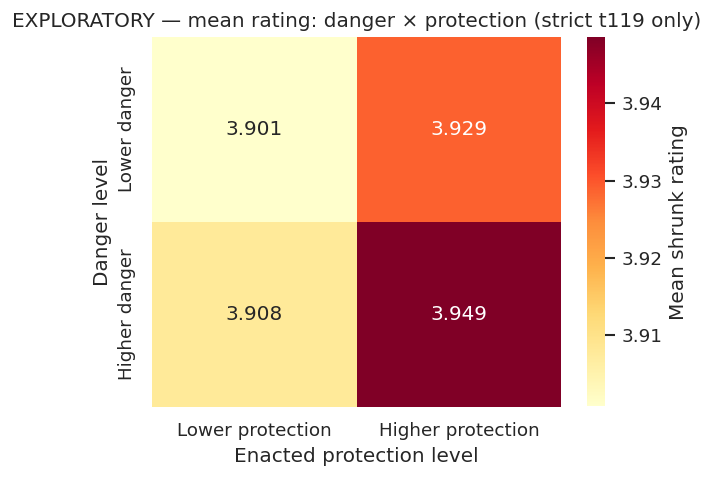

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/figures/danger_x_protection_heatmap_moderate_plus_fractional.png


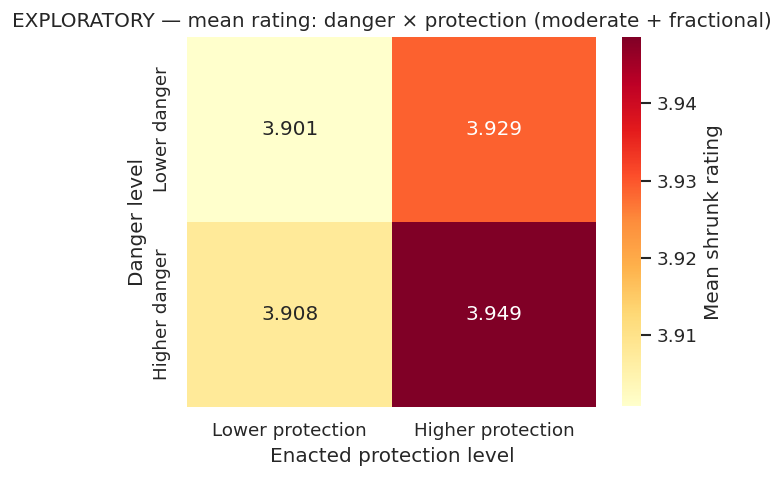

In [8]:
import seaborn as sns

interaction_rows = []
quad_frames = []
prot_specs = [
    ("EXP_enacted_protection_strict", "strict t119 only"),
    ("EXP_enacted_protection_moderate", "moderate + fractional"),
    ("EXP_enacted_protection_broad", "broad enacted"),
]
for prot_col, label in prot_specs:
    if prot_col not in work_exp.columns:
        continue
    tmp = work_exp.copy()
    tmp[prot_col] = tmp[prot_col].fillna(0.0)
    inter = ex.danger_protection_interaction(
        tmp.set_index("book_id") if "book_id" in tmp.columns else tmp,
        protection_col=prot_col,
    )
    row = {"protection_index": label, "protection_col": prot_col}
    for term in ("z_danger", "z_protection", "z_danger_x_z_protection"):
        payload = inter.get(term) or {}
        row[f"{term}_beta"] = payload.get("beta")
        row[f"{term}_se"] = payload.get("se")
        row[f"{term}_p"] = payload.get("p")
    interaction_rows.append(row)
    q = ex.danger_protection_quadrants(
        tmp,
        protection_col=prot_col,
        protection_label=label,
    )
    if len(q):
        quad_frames.append(q)

interaction_df = pd.DataFrame(interaction_rows)
display(interaction_df.round(4))
ctx.save_table(interaction_df, "danger_x_protection_interaction")

quad_all = pd.concat(quad_frames, ignore_index=True) if quad_frames else pd.DataFrame()
display(quad_all.round(4))
ctx.save_table(quad_all, "danger_x_protection_quadrants")

# Heatmaps for strict and moderate
_DANGER_LABELS = {"lower_danger": "Lower danger", "higher_danger": "Higher danger"}
_PROT_LABELS = {"lower_protection": "Lower protection", "higher_protection": "Higher protection"}

for label in ("strict t119 only", "moderate + fractional"):
    sub = quad_all[quad_all["protection_index"] == label] if len(quad_all) else pd.DataFrame()
    if sub.empty:
        continue
    mat = sub.pivot(index="danger_bin", columns="protection_bin", values="mean_rating")
    row_order = [r for r in ("lower_danger", "higher_danger") if r in mat.index]
    col_order = [c for c in ("lower_protection", "higher_protection") if c in mat.columns]
    mat = mat.reindex(index=row_order, columns=col_order)
    mat.index = [_DANGER_LABELS.get(r, r) for r in mat.index]
    mat.columns = [_PROT_LABELS.get(c, c) for c in mat.columns]
    fig, ax = plt.subplots(figsize=(5.5, 4))
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Mean shrunk rating"})
    ax.set_xlabel("Enacted protection level")
    ax.set_ylabel("Danger level")
    ax.set_title(f"EXPLORATORY — mean rating: danger × protection ({label})")
    safe = label.replace(" ", "_").replace("+", "plus")
    ctx.save_figure(fig, f"danger_x_protection_heatmap_{safe}")
    plt.show()

## Emotional security × appearance quadrants

In [9]:
if "EXP_emotional_security_strict" in work_exp.columns and "EXP_appearance_strict" in work_exp.columns:
    quad_df = ex.quadrant_summary(
        work_exp.set_index("book_id") if "book_id" in work_exp.columns else work_exp,
        "EXP_emotional_security_strict",
        "EXP_appearance_strict",
    )
    display(quad_df.round(4))
    ctx.save_table(quad_df, "care_x_appearance_quadrants")

,_quad,rating_shrunk_mean,rating_shrunk_median,count
0,high_care_high_appearance,3.9131,3.9100,4275
1,high_care_low_appearance,3.9383,3.9245,3725
2,low_care_high_appearance,3.9056,3.9041,3725
3,low_care_low_appearance,3.9311,3.9174,4274


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/care_x_appearance_quadrants.csv  (4 rows)


## Fractional protection vs strict t119-only

In [10]:
compare_rows = []
for col in [
    "EXP_enacted_protection_strict",
    "EXP_enacted_protection_moderate",
    "RAX_external_protection",
]:
    if col not in work_exp.columns:
        continue
    res = _test(work_exp, col, "H4", label=col)
    compare_rows.append(
        {
            "index": col,
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
        }
    )
frac_compare = pd.DataFrame(compare_rows)
display(frac_compare.round(4))
ctx.save_table(frac_compare, "fractional_vs_strict_protection")
print("Exploratory notebook complete — results do not modify confirmatory H1–H6 verdicts.")

,index,cliffs_delta,ci_low,ci_high,verdict
0,EXP_enacted_protection_strict,0.1597,0.1410,0.1816,clears_gate
1,EXP_enacted_protection_moderate,0.1597,0.1410,0.1816,clears_gate
2,RAX_external_protection,0.1597,0.1410,0.1816,clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/fractional_vs_strict_protection.csv  (3 rows)
Exploratory notebook complete — results do not modify confirmatory H1–H6 verdicts.
